In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Primeras filas del dataset:
  cliente     importe  n_productos
0     C01  229.802849     2.530526
1     C02  191.704142     3.542560
2     C03  238.861312     2.536582
3     C04  291.381791     2.534270
4     C05  185.950798     3.241962 

Centroides iniciales (tomados de puntos del dataset):
       importe  n_productos
0  1748.058084    13.768703
1   291.381791     2.534270
2   185.951783     1.086720 

Asignación (iteración 0) — primeras 10 filas:
  cliente     importe  n_productos  cluster
0     C01  229.802849     2.530526        2
1     C02  191.704142     3.542560        2
2     C03  238.861312     2.536582        1
3     C04  291.381791     2.534270        1
4     C05  185.950798     3.241962        2
5     C06  185.951783     1.086720        2
6     C07  294.752769     1.275082        1
7     C08  246.046084     2.437712        1
8     C09  678.460266     7.183426        1
9     C10  837.709680     8.166384        1 



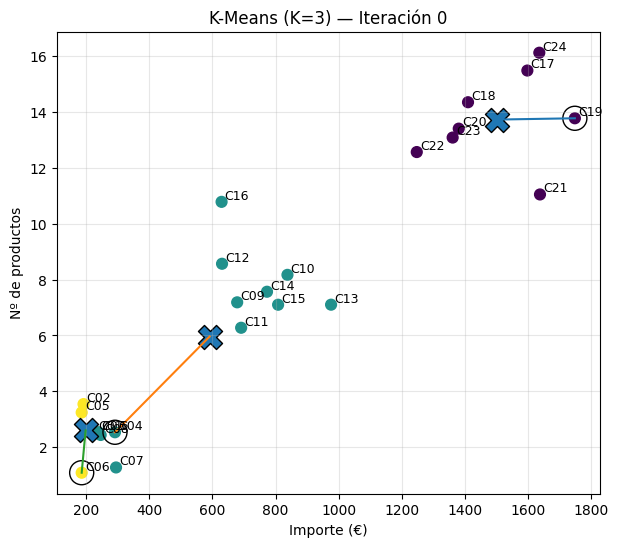

Asignación (iteración 1) — primeras 10 filas:
  cliente     importe  n_productos  cluster
0     C01  229.802849     2.530526        2
1     C02  191.704142     3.542560        2
2     C03  238.861312     2.536582        2
3     C04  291.381791     2.534270        2
4     C05  185.950798     3.241962        2
5     C06  185.951783     1.086720        2
6     C07  294.752769     1.275082        2
7     C08  246.046084     2.437712        2
8     C09  678.460266     7.183426        1
9     C10  837.709680     8.166384        1 



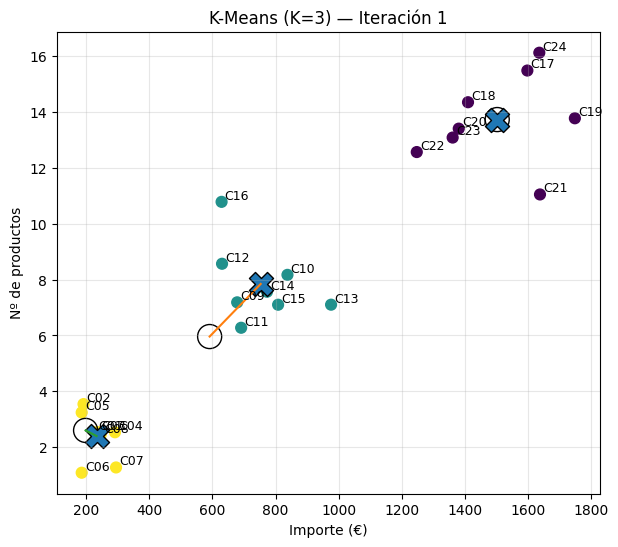

Asignación (iteración 2) — primeras 10 filas:
  cliente     importe  n_productos  cluster
0     C01  229.802849     2.530526        2
1     C02  191.704142     3.542560        2
2     C03  238.861312     2.536582        2
3     C04  291.381791     2.534270        2
4     C05  185.950798     3.241962        2
5     C06  185.951783     1.086720        2
6     C07  294.752769     1.275082        2
7     C08  246.046084     2.437712        2
8     C09  678.460266     7.183426        1
9     C10  837.709680     8.166384        1 



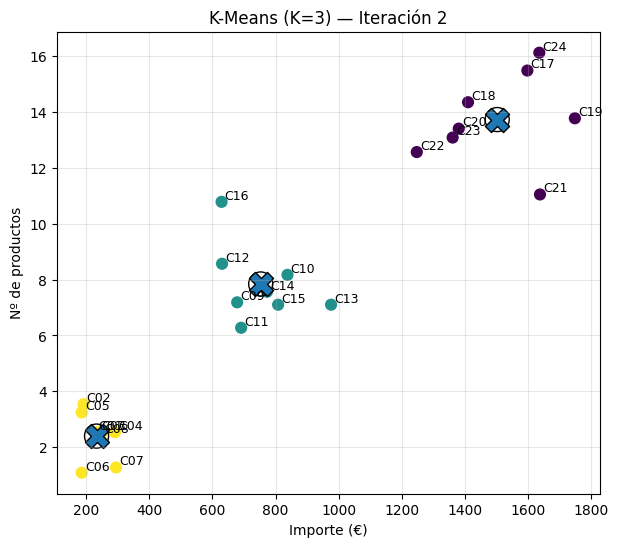

Convergió en la iteración 2.

Resultado final (ordenado por cluster):
cliente     importe  n_productos  cluster_final
    C24 1635.435022    16.114244              0
    C22 1247.259378    12.560312              0
    C21 1637.595447    11.042956              0
    C20 1380.248143    13.397793              0
    C19 1748.058084    13.768703              0
    C18 1409.612033    14.342737              0
    C17 1597.570500    15.476933              0
    C23 1360.926511    13.078722              0
    C16  629.030218    10.778417              1
    C15  808.103385     7.097440              1
    C14  772.906844     7.562459              1
    C13  975.877852     7.099042              1
    C12  630.523556     8.563547              1
    C10  837.709680     8.166384              1
    C09  678.460266     7.183426              1
    C11  691.037111     6.273510              1
    C08  246.046084     2.437712              2
    C07  294.752769     1.275082              2
    C06  185.95178

In [3]:


# -----------------------------
# 1) Dataset "clientes" (tonto)
# -----------------------------
np.random.seed(42)

def make_group(n, importe_mu, importe_sigma, prod_mu, prod_sigma):
    importe = np.random.normal(importe_mu, importe_sigma, n)
    n_prod  = np.random.normal(prod_mu, prod_sigma, n)
    return np.column_stack([importe, n_prod])

# 3 grupos "naturales" (solo para simular datos)
g1 = make_group(8,  200,  60,  3, 1.0)   # bajo importe / pocos productos
g2 = make_group(8,  800, 120,  8, 1.5)   # medio
g3 = make_group(8, 1600, 180, 14, 2.0)   # alto

X = np.vstack([g1, g2, g3])

# Limpiar para que no haya negativos raros
X[:, 0] = np.clip(X[:, 0], 50, None)      # importe >= 50
X[:, 1] = np.clip(X[:, 1], 1, None)       # n_productos >= 1

# IDs de clientes
ids = [f"C{str(i+1).zfill(2)}" for i in range(len(X))]

df = pd.DataFrame(X, columns=["importe", "n_productos"])
df.insert(0, "cliente", ids)

print("Primeras filas del dataset:")
print(df.head(), "\n")


# -----------------------------------------
# 2) K-Means "a mano" para ver el proceso
# -----------------------------------------
def assign_clusters(X, centroids):
    # Distancias euclídeas: cada punto contra cada centroide
    # Resultado: matriz (n_puntos x k)
    dists = np.sqrt(((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2))
    return dists.argmin(axis=1)

def update_centroids(X, labels, k, old_centroids):
    centroids = old_centroids.copy()
    for c in range(k):
        pts = X[labels == c]
        if len(pts) > 0:
            centroids[c] = pts.mean(axis=0)
        else:
            # Si un cluster queda vacío, re-inicializa ese centroide a un punto aleatorio
            centroids[c] = X[np.random.randint(0, len(X))]
    return centroids

def plot_iteration(X, ids, centroids, old_centroids, labels, it):
    plt.figure(figsize=(7, 6))

    # Puntos coloreados por cluster (colormap por defecto)
    plt.scatter(X[:, 0], X[:, 1], c=labels, s=60)

    # Centroides anteriores (si existen) y actuales
    if old_centroids is not None:
        plt.scatter(old_centroids[:, 0], old_centroids[:, 1], s=300, marker="o",
                    facecolors="none", edgecolors="k")
        # Líneas de movimiento (sin fijar colores)
        for i in range(len(centroids)):
            plt.plot([old_centroids[i, 0], centroids[i, 0]],
                     [old_centroids[i, 1], centroids[i, 1]])

    plt.scatter(centroids[:, 0], centroids[:, 1], s=300, marker="X", edgecolors="k")

    # Etiquetas de cliente (para ver "cada cliente")
    for (x, y), cid in zip(X, ids):
        plt.text(x + 10, y + 0.1, cid, fontsize=9)

    plt.title(f"K-Means (K=3) — Iteración {it}")
    plt.xlabel("Importe (€)")
    plt.ylabel("Nº de productos")
    plt.grid(True, alpha=0.3)
    plt.show()


# -----------------------------------------
# 3) Ejecutar iteraciones y visualizar
# -----------------------------------------
k = 3
max_iter = 6

# Inicialización: elegimos 3 puntos aleatorios como centroides iniciales
init_idx = np.random.choice(len(X), size=k, replace=False)
centroids = X[init_idx].copy()

print("Centroides iniciales (tomados de puntos del dataset):")
print(pd.DataFrame(centroids, columns=["importe", "n_productos"]), "\n")

old_centroids = None

for it in range(max_iter):
    labels = assign_clusters(X, centroids)

    # Mostrar asignación de clientes (tabla)
    df_it = df.copy()
    df_it["cluster"] = labels
    print(f"Asignación (iteración {it}) — primeras 10 filas:")
    print(df_it.head(10), "\n")

    # Calcular nuevos centroides
    new_centroids = update_centroids(X, labels, k, centroids)

    # Plot de esta iteración (muestra centroides antiguos->nuevos)
    plot_iteration(X, ids, new_centroids, centroids, labels, it)

    # Parada si no cambian los centroides
    if np.allclose(new_centroids, centroids):
        print(f"Convergió en la iteración {it}.")
        centroids = new_centroids
        break

    old_centroids = centroids
    centroids = new_centroids


# -----------------------------------------
# 4) Resultado final (tabla completa)
# -----------------------------------------
final_labels = assign_clusters(X, centroids)
df_final = df.copy()
df_final["cluster_final"] = final_labels

print("\nResultado final (ordenado por cluster):")
print(df_final.sort_values("cluster_final").to_string(index=False))
